In [4]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

print("Everything working!")

Everything working!


In [ ]:
import pandas as pd
df = pd.read_csv("D:\\MACHINE LEARNING\\GNN\\GNN_Foundations\\Project\\Data\\bindingdb_highconf_pKd_clean.csv")

print(df.head())
print(df.shape)

                                 compound_iso_smiles  \
0  O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(CCCCCC(O)=...   
1  O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(C\C=C\c2cn...   
2  O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(CC2CC2)C(=...   
3  OCCCCCCN1[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@...   
4  OCCCCCN1[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H...   

                                     target_sequence  affinity  
0  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  9.619789  
1  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  9.602060  
2  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  9.387216  
3  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  9.096910  
4  PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...  9.004365  
(2081891, 3)


In [10]:
print("Rows:", len(df))

Rows: 2081891


In [9]:
print(df.shape)

print(df['compound_iso_smiles'].nunique())

print(df['target_sequence'].nunique())

print(df['affinity'].describe())

(2081891, 3)
1114117
8289
count    2.081891e+06
mean     6.785868e+00
std      1.444599e+00
min      3.000000e+00
25%      5.715914e+00
50%      6.795880e+00
75%      7.823909e+00
max      1.498716e+01
Name: affinity, dtype: float64


In [11]:
df_small = df.sample(
    n=20000,
    random_state=42
).reset_index(drop=True)

In [12]:
print(df_small.shape)
print(df_small['compound_iso_smiles'].nunique())
print(df_small['target_sequence'].nunique())

(20000, 3)
19523
2870


Smiles data: CCO

rdkit Lib: C -- C -- O

In [13]:
from rdkit import Chem

smiles = df_small.iloc[0]['compound_iso_smiles']

mol = Chem.MolFromSmiles(smiles)

print("Atoms:", mol.GetNumAtoms())
print("Bonds:", mol.GetNumBonds())

Atoms: 32
Bonds: 35


In [14]:
for atom in mol.GetAtoms():
    print(atom.GetSymbol(), atom.GetAtomicNum())

C 6
O 8
C 6
C 6
C 6
C 6
C 6
C 6
C 6
C 6
N 7
C 6
C 6
C 6
C 6
C 6
C 6
C 6
S 16
O 8
O 8
N 7
C 6
C 6
C 6
N 7
C 6
N 7
C 6
F 9
F 9
F 9


In [15]:
import torch
from rdkit import Chem
from torch_geometric.data import Data

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    # Node features
    x = []
    for atom in mol.GetAtoms():
        x.append([atom.GetAtomicNum()])

    x = torch.tensor(x, dtype=torch.float)

    # Edges
    edges = []

    for bond in mol.GetBonds():

        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        edges.append([start, end])
        edges.append([end, start])

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    return Data(
        x=x,
        edge_index=edge_index
    )

In [19]:
graph = smiles_to_graph(
    df_small.iloc[0]["compound_iso_smiles"]
)

print(graph)
print(graph.x.shape)
print(graph.edge_index.shape)

Data(x=[32, 1], edge_index=[2, 70])
torch.Size([32, 1])
torch.Size([2, 70])


In [20]:
import torch
from rdkit import Chem
from torch_geometric.data import Data


# -------------------------
# Atom Feature Extraction
# -------------------------

def atom_features(atom):
    """
    Extract features for each atom.
    Returns a list of numerical features.
    """

    return [
        atom.GetAtomicNum(),                  # Atomic number
        atom.GetDegree(),                     # Number of neighboring atoms
        atom.GetFormalCharge(),              # Formal charge
        int(atom.GetIsAromatic()),           # Aromatic atom or not
        atom.GetTotalNumHs(),                # Number of hydrogens
        int(atom.GetHybridization())         # Hybridization type
    ]


# -------------------------
# SMILES -> Graph Conversion
# -------------------------

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    # -------------------------
    # Node Features
    # -------------------------
    node_features = []

    for atom in mol.GetAtoms():
        node_features.append(atom_features(atom))

    x = torch.tensor(node_features, dtype=torch.float)

    # -------------------------
    # Edge Index
    # -------------------------
    edges = []

    for bond in mol.GetBonds():

        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        # Add both directions for undirected graph
        edges.append([start, end])
        edges.append([end, start])

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    # -------------------------
    # Create PyG Data Object
    # -------------------------
    graph = Data(
        x=x,
        edge_index=edge_index
    )

    return graph

In [21]:
sample_smiles = df_small.iloc[0]["compound_iso_smiles"]

graph = smiles_to_graph(sample_smiles)

print(graph)
print()

print("Node feature matrix shape:", graph.x.shape)
print("Edge index shape:", graph.edge_index.shape)

print("\nFirst 5 node features:")
print(graph.x[:5])

print("\nFirst 10 edges:")
print(graph.edge_index[:, :10])

Data(x=[32, 6], edge_index=[2, 70])

Node feature matrix shape: torch.Size([32, 6])
Edge index shape: torch.Size([2, 70])

First 5 node features:
tensor([[6., 1., 0., 0., 3., 4.],
        [8., 2., 0., 0., 0., 3.],
        [6., 3., 0., 1., 0., 3.],
        [6., 2., 0., 1., 1., 3.],
        [6., 3., 0., 1., 0., 3.]])

First 10 edges:
tensor([[0, 1, 1, 2, 2, 3, 3, 4, 4, 5],
        [1, 0, 2, 1, 3, 2, 4, 3, 5, 4]])


In [22]:
amino_dict = {
    aa: idx + 1
    for idx, aa in enumerate(
        "ACDEFGHIKLMNPQRSTVWY"
    )
}

MAX_LEN = 1000

def encode_protein(sequence):

    encoded = [
        amino_dict.get(aa, 0)
        for aa in sequence[:MAX_LEN]
    ]

    if len(encoded) < MAX_LEN:
        encoded += [0] * (MAX_LEN - len(encoded))

    return torch.tensor(
        encoded,
        dtype=torch.long
    )

In [23]:
protein = df_small.iloc[0]["target_sequence"]

encoded_protein = encode_protein(protein)

print(encoded_protein.shape)
print(encoded_protein[:30])

torch.Size([1000])
tensor([11,  1, 11, 10, 13, 13, 13,  6, 13, 14, 16,  5, 18,  7,  5, 17,  9, 14,
        16, 10,  1, 10,  8,  4, 14, 15,  8,  1,  4, 15])


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)


class DTI_GCN(nn.Module):

    def __init__(self):
        super().__init__()

        # -------------------------
        # Drug Graph Encoder
        # -------------------------
        self.gcn1 = GCNConv(6, 64)
        self.gcn2 = GCNConv(64, 128)

        # -------------------------
        # Protein Encoder
        # -------------------------
        self.embedding = nn.Embedding(
            num_embeddings=21,
            embedding_dim=128,
            padding_idx=0
        )

        self.conv1 = nn.Conv1d(
            in_channels=128,
            out_channels=64,
            kernel_size=8
        )

        # -------------------------
        # Prediction Head
        # -------------------------
        self.fc1 = nn.Linear(
            128 + 64,
            128
        )

        self.fc2 = nn.Linear(
            128,
            1
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
        protein
    ):

        # -------------------------
        # Drug Branch
        # -------------------------
        x = self.gcn1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.gcn2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        # -------------------------
        # Protein Branch
        # -------------------------
        protein = self.embedding(
            protein
        )

        protein = protein.permute(
            0,
            2,
            1
        )

        protein = F.relu(
            self.conv1(
                protein
            )
        )

        protein = torch.max(
            protein,
            dim=2
        )[0]

        # -------------------------
        # Fusion
        # -------------------------
        combined = torch.cat(
            [x, protein],
            dim=1
        )

        combined = F.relu(
            self.fc1(
                combined
            )
        )

        output = self.fc2(
            combined
        )

        return output

In [25]:
df_small = df.sample(
    n=10000,
    random_state=42
).reset_index(drop=True)

print(df_small.shape)

(10000, 3)


In [26]:
dataset = []

for idx, row in df_small.iterrows():

    graph = smiles_to_graph(
        row["compound_iso_smiles"]
    )

    if graph is None:
        continue

    protein = encode_protein(
        row["target_sequence"]
    )

    affinity = torch.tensor(
        [row["affinity"]],
        dtype=torch.float
    )

    dataset.append(
        (
            graph,
            protein,
            affinity
        )
    )

print("Samples:", len(dataset))

[00:26:07] Explicit valence for atom # 10 N, 4, is greater than permitted


Samples: 9999


In [27]:
graph, protein, affinity = dataset[0]

print(graph)
print(protein.shape)
print(affinity)

Data(x=[32, 6], edge_index=[2, 70])
torch.Size([1000])
tensor([7.3979])


In [28]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

print(len(train_data))
print(len(test_data))

7999
2000


In [29]:
from torch_geometric.data import Batch

def collate_fn(batch):

    graphs, proteins, labels = zip(*batch)

    graph_batch = Batch.from_data_list(
        graphs
    )

    proteins = torch.stack(
        proteins
    )

    labels = torch.stack(
        labels
    )

    return (
        graph_batch,
        proteins,
        labels
    )

In [30]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [31]:
graph_batch, proteins, labels = next(
    iter(train_loader)
)

print(graph_batch)
print(proteins.shape)
print(labels.shape)

DataBatch(x=[970, 6], edge_index=[2, 2144], batch=[970], ptr=[33])
torch.Size([32, 1000])
torch.Size([32, 1])


In [32]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = DTI_GCN().to(device)

print(model)

DTI_GCN(
  (gcn1): GCNConv(6, 64)
  (gcn2): GCNConv(64, 128)
  (embedding): Embedding(21, 128, padding_idx=0)
  (conv1): Conv1d(128, 64, kernel_size=(8,), stride=(1,))
  (fc1): Linear(in_features=192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [33]:
graph_batch = graph_batch.to(device)
proteins = proteins.to(device)
labels = labels.to(device)

In [34]:
criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for graph_batch, proteins, labels in train_loader:

        graph_batch = graph_batch.to(device)
        proteins = proteins.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch,
            proteins
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/10 Loss: 2.7109
Epoch 2/10 Loss: 1.8848
Epoch 3/10 Loss: 1.8308
Epoch 4/10 Loss: 1.7682
Epoch 5/10 Loss: 1.7294
Epoch 6/10 Loss: 1.7297
Epoch 7/10 Loss: 1.6991
Epoch 8/10 Loss: 1.6541
Epoch 9/10 Loss: 1.6545
Epoch 10/10 Loss: 1.6144


In [36]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

model.eval()

predictions = []
targets = []

with torch.no_grad():

    for graph_batch, proteins, labels in test_loader:

        graph_batch = graph_batch.to(device)
        proteins = proteins.to(device)

        outputs = model(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch,
            proteins
        )

        predictions.extend(
            outputs.cpu().numpy().flatten()
        )

        targets.extend(
            labels.numpy().flatten()
        )

In [37]:
mse = mean_squared_error(
    targets,
    predictions
)

rmse = mse ** 0.5

mae = mean_absolute_error(
    targets,
    predictions
)

r2 = r2_score(
    targets,
    predictions
)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

RMSE: 1.4315
MAE : 1.1561
R²  : -0.0297


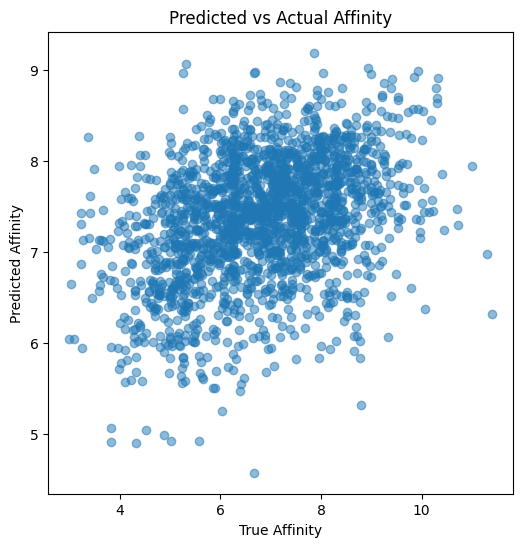

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    targets,
    predictions,
    alpha=0.5
)

plt.xlabel("True Affinity")
plt.ylabel("Predicted Affinity")

plt.title(
    "Predicted vs Actual Affinity"
)

plt.show()